# Ejercicio Módulo 5 - Dataset Swiss
**Inteligencia Artificial - CEIA - FIUBA**

**Sztenbger Ian**

Para aprender sobre regresión, vamos a utilizar un dataset clásico llamado Swiss, que proviene originalmente del lenguaje R. Este dataset contiene datos socioeconómicos de 47 provincias suizas a fines del siglo XIX. Cada fila representa una provincia, y las variables reflejan características demográficas y sociales relevantes para ese contexto histórico.

## Variables

- `Location`: Provincia donde se midieron los datos.
- `Fertility`: Tasa de fertilidad (número promedio de hijos por mujer)
- `Agriculture`:` Porcentaje de hombres ocupados en agricultura
- `Examination`: Porcentaje de hombres que completaron exámenes de educación superior
- `Education`: Nivel promedio de educación (escala arbitraria)
- `Catholic`: Porcentaje de población católica
- `Infant.Mortality`: Tasa de mortalidad infantil (por cada 1000 nacidos vivos)

## Que queremos predecir?

Vamos a utilizar este dataset para predecir la tasa de fertilidad en cada provincia mediante diferentes métodos de regresión.

--- 

Siguiendo el procedimiento típico de Machine Learning, vamos a leer los datos y separarlos en los datasets de entrenamiento y testeo utilizando Scikit-Learn...

In [2]:
import pandas as pd

df = pd.read_csv("swiss.csv")

df.head()

,Location,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
0,Courtelary,80.2,17.0,15,12,9.96,22.2
1,Delemont,83.1,45.1,6,9,84.84,22.2
2,Franches-Mnt,92.5,39.7,5,5,93.40,20.2
3,Moutier,85.8,36.5,12,7,33.77,20.3
4,Neuveville,76.9,43.5,17,15,5.16,20.6


In [3]:
print(f"Tenemos {df.shape[0]} observaciones")

Tenemos 47 observaciones


Obtenemos la variable objetivo (`Fertility`) y, por otro lado, los atributos (quitamos `Location` ya que no es un atributo numérico relevante para la regresión)

In [4]:
X = df.drop(["Fertility", "Location"], axis=1)
y = df["Fertility"]

Dado que tenemos pocas observaciones, vamos a separar el dataset en un 50% para entrenamiento y 50% para testeo:

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

## Regresión lineal múltiple

Arranquemos la primera parte del ejercicio. Para eso, vamos a entrenar un modelo de regresión lineal múltiple usando todos los atributos. Para ello debes:

1. Escalar los atributos usando `StandardScaler`
2. Entrenar el modelo usando el dataset de entrenamiento.
3. Obtener las predicciones sobre el dataset de testeo.
4. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

###########

#agrego el ColumnTransformer para definir mi "step" de preprocesamiento a utilizar en el pipeline
from sklearn.compose import ColumnTransformer
"""
#Escalado de datos sin utilizar ColumnTransformer

#defino scaler
scaler = StandardScaler()

#aplico la estandarizacion a mis datos de train
X_train_scaled = scaler.fit_transform(X_train)

#obtengo el DataFrame de Train escalado
X_train_scaled_df = X_train.copy()
X_train_scaled_df[['Agriculture',	'Examination',	'Education',	'Catholic',	'Infant.Mortality']] = X_train_scaled
X_train_scaled_df
"""
#entrenar modelo

# Definimos qué columnas son categóricas y cuáles numéricas
numerical_columns = ['Agriculture',	'Examination',	'Education',	'Catholic',	'Infant.Mortality']

# Creamos el preprocesamiento para las columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns)    # Escalamos las variables numéricas
    ]
)

# Creamos el pipeline con preprocesamiento y modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())  # Aplicamos la regresión lineal
])

In [ ]:
#Utilizo el pipeline definido, sobre los datos de entrenamiento
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Agriculture', 'Examination',
                                                   'Education', 'Catholic',
                                                   'Infant.Mortality'])])),
                ('regressor', LinearRegression())])

In [ ]:
#realizo las predicciones sobre el set de validación y veo los 5 primeros registros
y_pred = pipeline.predict(X_test)
y_pred[:5]

array([57.42828964, 80.37882378, 62.63618648, 79.20635709, 68.77733438])

In [ ]:
#obtenemos las métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


print("R-cuadrado en test:", round(r2, 3))
print("Error absoluto medio:", round(mae, 3))
print("Error cuadrático medio:", round(mse, 3))


R-cuadrado en test: 0.574
Error absoluto medio: 6.094
Error cuadrático medio: 64.457


## Modelo con regularización

Para mejorar nuestro modelo, vamos a explorar técnicas de regresión lineal con regularización, que nos permiten controlar el sobreajuste y seleccionar variables relevantes automáticamente.

Existen dos variantes muy populares:

- Una penaliza la suma de los cuadrados de los coeficientes (regularización L2).
- La otra penaliza la suma del valor absoluto de los coeficientes (regularización L1).

Ambas ayudan a mejorar la generalización, pero una de ellas además puede eliminar variables (coeficientes exactamente cero), lo que ayuda a identificar qué atributos son realmente importantes.

Tu tarea:

1. Elegí correctamente cuál de los dos métodos de regularización usar para este problema. 
    - Pista: Queremos que el modelo sea capaz de hacer una selección automática de variables, dejando fuera aquellas que no aportan.
2. Implementá un pipeline que incluya escalado y el modelo elegido.
3. Buscá automáticamente el mejor valor del hiperparámetro de regularización (alpha) usando validación cruzada usando 3-folds.
4. Entrená el modelo con los datos de entrenamiento y obtené las predicciones para el set de testeo.
5. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.
6. Imprimí los coeficientes resultantes e identificá qué variables fueron eliminadas (coeficiente = 0).

In [1]:
import numpy as np

from sklearn.linear_model import LassoCV, RidgeCV

Paremos un momento para entender qué hacen LassoCV y RidgeCV antes de continuar con la resolución:

> Tanto `LassoCV` como `RidgeCV` son implementaciones de regresión lineal con regularización que incluyen la búsqueda automática del mejor hiperparámetro alpha mediante validación cruzada.
>
> Ambos métodos prueban distintos valores de alpha y eligen el que minimiza el error del modelo, facilitando el proceso de ajuste sin necesidad de una búsqueda manual.
>
> Internamente, utilizan la métrica del error cuadrático medio (MSE) para evaluar el rendimiento del modelo en cada fold de la validación cruzada.
>
> Por ejemplo, si llamás a RidgeCV(alphas=alphas, cv=5), se hará una validación cruzada de 5 folds utilizando los valores de alpha que vos le pases, y se seleccionará el que obtenga el menor MSE promedio.
> 
> Una vez elegido el mejor alpha, el modelo final se entrena con todos los datos de entrenamiento usando ese valor.

¡Listo! Con todo lo que vimos hasta ahora, ya estás en condiciones de resolver esta parte y completar los 6 puntos propuestos

In [ ]:
alphas = np.logspace(-4, 1, 500)

##### COMPLETAR AQUI LO PEDIDO

#1. Elegimos método de regularización L1: Regresión de Lasso. Ya que este método, al tener la capacidad de hacer exactamente 0 el valor 
#   de algunos parámetros al incrementar alpha, nos sirve para descartar atributos que no aportar valor al modelo

#2. Implementá un pipeline que incluya escalado y el modelo elegido.

# Creamos el preprocesamiento para las columnas
numerical_columns_lasso = ['Agriculture',	'Examination',	'Education',	'Catholic',	'Infant.Mortality']
#pre-procesador para el regresor de Lasso
preprocessor_lasso = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns_lasso)    # Escalamos las variables numéricas
    ]
)


#Regresor de Lasso que busca el mejor alpha, utilizando cross validation "KFold" con tres folds
#LassoCV(alphas=alphas,cv=3)

#defino mi pipeline para aplicar la regresión de lasso
pipeline_lasso = Pipeline(steps=[
    ('preprocessor',preprocessor_lasso),
    ('regressor',LassoCV(alphas=alphas,cv=3))
])

#3. Buscá automáticamente el mejor valor del hiperparámetro de regularización (alpha) usando validación cruzada usando 3-folds.
#entrenamos la regresion lineal
pipeline_lasso.fit(X_train,y_train)

#imprimo el mejor alpha encontrado
best_alpha = pipeline_lasso.named_steps['regressor'].alpha_
print(f"El valor de alpha más óptimo encontrado es {best_alpha:.2f}")


#4. Entrená el modelo con los datos de entrenamiento y obtené las predicciones para el set de testeo.
y_pred_lasso = pipeline_lasso.predict(X_test)

#5. Calcular las métricas MAE, MSE  y $R^2$, e imprimir los resultados.
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)


print("R-cuadrado en test:", round(r2_lasso, 3))
print("Error absoluto medio:", round(mae_lasso, 3))
print("Error cuadrático medio:", round(mse_lasso, 3))

#6. Imprimí los coeficientes resultantes e identificá qué variables fueron eliminadas (coeficiente = 0).
print(f"Los valores de los coeficientes de Lasso son {np.round(pipeline_lasso.named_steps['regressor'].coef_, 2)}")

El valor de alpha más óptimo encontrado es 2.18
R-cuadrado en test: 0.576
Error absoluto medio: 5.995
Error cuadrático medio: 64.294
Los valores de los coeficientes de Lasso son [-0.   -1.76 -2.4   1.72  3.2 ]


<p>Observamos que se eliminó uno sólo de los atributos: "Agriculture". Podemos ver un gráfico de correlación, para revisar cómo es la correlación de los atributos con el target y si esto tiene sentido</p>

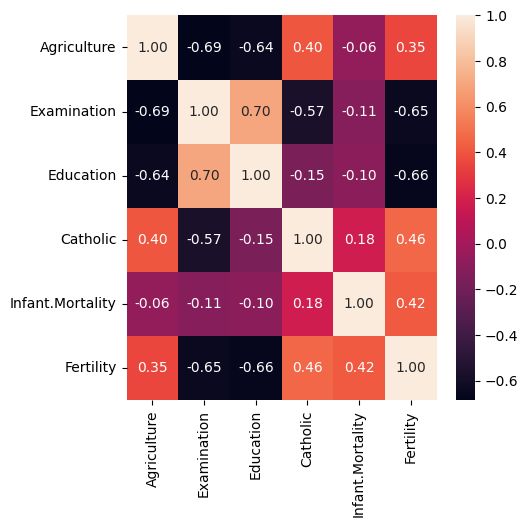

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[['Agriculture',	'Examination',	'Education',	'Catholic',	'Infant.Mortality','Fertility']].corr()
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cbar=True)
plt.show()

<p>Se observa que el atriuto 'Fertility', era el que menor correlación poseía con el target</p>
<p>Por otro lado, es interesante observa que la correlación inversa de 'Examination' y 'Education', se traslada a coeficientes negaivos en el modelo</p>

## Comparación de modelos y conclusiones

Completá la siguiente tabla con las métricas obtenidas para cada uno de los modelos que entrenaste:

| Modelo                        | MAE | MSE | $R^2$ |
| ----------------------------- | --- | --- | ----- |
| Regresión Lineal              |6.094|64.457|0.574  |
| Modelo Regularizado (Lasso)   |5.995|64.294| 0.576 |


> ⚠️ Asegurate de cambiar el nombre del modelo `Modelo Regularizado (L1 o L2)` según el modelo que usaste (Lasso o Ridge).

### Justificación

**¿Cuál de los modelos te parece que tuvo un mejor desempeño general?**

Tené en cuenta las tres métricas al responder, y también pensá en la complejidad del modelo (por ejemplo, si eliminó variables innecesarias).

Escribí tu respuesta a continuación:

<p>Revisando las métricas, podemos observar una mejor performance del modelo de Lasso (se disminuye tanto el error absoluto como el error cuadrático y aumenta el R<sup>2</sup>), aunque estas mejoras no son muy significativas. Sin embargo, cabe destacar, que estos resultados son obtenidos luego de que hemos eliminado un feature que no aportaba información valiosa, logrando un modelo más simple que el de la Regresión Lineal.</p>   
<p>Con lo expuesto anteriormente, podemos afirmar que el modelo de <i>Lasso posee un mejor desempeño general, ya que logra mejores métricas con un modeo más simple</i></p>